# Tech Challenge — Fase 3: Predição e Inteligência Analítica para Alfabetização no Brasil
## Notebook 01: Análise Exploratória de Dados (EDA) e Validação de Hipóteses
**POSTECH / FIAP — AI Scientist**

Este notebook executa a análise exploratória completa da base analítica (`abt_alfabetizacao`)
armazenada no Google BigQuery (Camada Gold), cobrindo:
1. Auditoria cadastral e perfil do target (`alfabetizado`);
2. As 6 Dimensões Analíticas de negócio;
3. Teste e validação das 5 Hipóteses Centrais do Edital;
4. Exportação das visualizações em alta resolução para a pasta `images/eda/`.


### 0. Configurações, Imports e Conexão com o Google BigQuery


In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Garante que os gráficos fiquem embutidos no notebook, e não só salvos em disco
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Pasta onde as figuras da EDA são exportadas em alta resolução
os.makedirs("images/eda", exist_ok=True)

In [2]:
# Conexão com o Google BigQuery.
# No Colab autentica na conta Google; localmente usa as credenciais do
# `gcloud auth application-default login`.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import auth
    auth.authenticate_user()
    os.system("pip install -q db-dtypes google-cloud-bigquery-storage")

from google.cloud import bigquery

PROJECT_ID = os.environ.get("GCP_PROJECT_ID", "tech-challenge-alfabetiza-25")
DATASET_GOLD = os.environ.get("BQ_DATASET_GOLD", "gold")
TABLE_ABT = f"{PROJECT_ID}.{DATASET_GOLD}.abt_alfabetizacao"

AMOSTRA_EDA = 50_000   # tamanho da amostra trazida para o pandas
SEED = 42

print(f"Conectando ao BigQuery no projeto: {PROJECT_ID}")
print(f"Tabela da camada Gold: {TABLE_ABT}")
client = bigquery.Client(project=PROJECT_ID)

Conectando ao BigQuery no projeto: tech-challenge-alfabetiza-25
Tabela da camada Gold: tech-challenge-alfabetiza-25.gold.abt_alfabetizacao


### 1. Carregamento dos Dados da Camada Gold
Como a base de alunos pode conter milhões de registros, extraímos uma amostra representativa
estratificada para visualizações finas no notebook, ou podemos consultar agregações diretas.


In [3]:
# A ABT tem 3.354.661 alunos. Para a EDA trazemos uma amostra aleatória ao
# pandas; as contagens oficiais da base saem de agregações no próprio BigQuery,
# logo abaixo, sem passar por amostra.
query_amostra = f"""
SELECT
  ano,
  id_aluno,
  id_escola,
  id_municipio,
  sigla_uf,
  nome_regiao,
  nome_municipio,
  porte_municipio,
  rede_label,
  peso_aluno,
  escola_qtd_alunos_avaliados,
  -- Socioeconômicas (SINTÉTICAS - ver o aviso da Dimensão 4)
  idhm,
  idhm_educacao,
  idhm_renda,
  pib_per_capita,
  indice_gini,
  taxa_abandono_fundamental,
  -- Indicadores do MESMO ano do aluno: descritivos
  mun_taxa_alfabetizacao,
  mun_media_portugues,
  mun_gap_meta_2024,
  -- Indicadores do ano ANTERIOR: os que podem virar feature
  mun_taxa_alfabetizacao_ant,
  mun_media_portugues_ant,
  mun_gap_meta_2024_ant,
  -- Nota do teste: define o alvo, entra aqui só para auditoria
  proficiencia_audit_only,
  alfabetizado
FROM `{TABLE_ABT}`
WHERE alfabetizado IS NOT NULL
ORDER BY RAND()
LIMIT {AMOSTRA_EDA};
"""

print("Executando query no BigQuery para carregar o DataFrame da EDA...")
df = client.query(query_amostra).to_dataframe()
print(f"Dados carregados com sucesso! Formato: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
df.head()

Executando query no BigQuery para carregar o DataFrame da EDA...


Dados carregados com sucesso! Formato: 50,000 linhas e 25 colunas.


,ano,id_aluno,id_escola,id_municipio,sigla_uf,nome_regiao,nome_municipio,porte_municipio,rede_label,peso_aluno,...,indice_gini,taxa_abandono_fundamental,mun_taxa_alfabetizacao,mun_media_portugues,mun_gap_meta_2024,mun_taxa_alfabetizacao_ant,mun_media_portugues_ant,mun_gap_meta_2024_ant,proficiencia_audit_only,alfabetizado
0,2023,23029663,60009559,2307650,CE,Nordeste,Maracanaú,Pequeno I (< 20k),Municipal,0.920517,...,0.510,2.96,88.30,788.449933,8.30,NaN,NaN,NaN,788.278722,1
1,2023,50726940,60040239,5007935,MS,Centro-Oeste,Sonora,Pequeno I (< 20k),Municipal,1.000000,...,0.547,1.15,47.50,734.321100,-5.30,NaN,NaN,NaN,755.190000,1
2,2024,35226744,60031126,3554102,SP,Sudeste,Taubaté,Pequeno I (< 20k),Municipal,1.294118,...,0.493,1.12,53.88,744.934000,3.78,44.37,730.5738,-5.73,664.259343,0
3,2024,26035558,60012308,2603454,PE,Nordeste,Camaragibe,Pequeno I (< 20k),Municipal,1.000000,...,0.546,2.23,57.57,738.780000,-4.63,58.66,747.0586,-3.54,759.800000,1
4,2024,32039326,60022907,3203320,ES,Sudeste,Marataízes,Pequeno II (20k - 50k),Municipal,1.130000,...,0.459,1.18,69.40,757.140000,-4.92,73.28,755.3532,-1.04,718.010000,0


### 1.1 Auditoria cadastral da base

Antes de qualquer gráfico: conferir o que a base tem. As contagens abaixo vêm de
agregações no BigQuery sobre a tabela inteira, não sobre a amostra.

In [4]:
query_audit = f"""
SELECT
  ano,
  COUNT(*)                        AS total_linhas,
  COUNT(DISTINCT id_aluno)        AS alunos_unicos,
  COUNT(DISTINCT id_municipio)    AS municipios_avaliados,
  COUNT(DISTINCT id_escola)       AS escolas_avaliadas,
  COUNTIF(alfabetizado IS NOT NULL) AS alunos_com_target,
  ROUND(AVG(alfabetizado) * 100, 2) AS taxa_alfabetizacao_pct,
  COUNTIF(mun_taxa_alfabetizacao_ant IS NOT NULL) AS com_indicador_ano_anterior
FROM `{TABLE_ABT}`
GROUP BY ano
ORDER BY ano ASC;
"""
df_audit = client.query(query_audit).to_dataframe()

print("=== COBERTURA DA BASE (gold.abt_alfabetizacao) ===")
display(df_audit)

print(f"Total de alunos na ABT: {df_audit['total_linhas'].sum():,}")
print(f"Modelável (com indicador do ano anterior): "
      f"{df_audit['com_indicador_ano_anterior'].sum():,}")

# Nulos por coluna, na amostra
nulos = (df.isna().mean() * 100).round(2)
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("\n=== COLUNAS COM VALORES AUSENTES (%, na amostra) ===")
print(nulos.to_string() if len(nulos) else "Nenhuma coluna com ausentes.")

=== COBERTURA DA BASE (gold.abt_alfabetizacao) ===


,ano,total_linhas,alunos_unicos,municipios_avaliados,escolas_avaliadas,alunos_com_target,taxa_alfabetizacao_pct,com_indicador_ano_anterior
0,2023,1502809,1502809,4871,36525,1502809,58.39,0
1,2024,1851852,1851852,5517,42328,1851852,59.78,1817470


Total de alunos na ABT: 3,354,661
Modelável (com indicador do ano anterior): 1,817,470

=== COLUNAS COM VALORES AUSENTES (%, na amostra) ===
mun_gap_meta_2024_ant         47.47
mun_taxa_alfabetizacao_ant    45.90
mun_media_portugues_ant       45.90
mun_gap_meta_2024              4.45


---
## Dimensão 1: Análise da Variável Alvo (`alfabetizado`)
*Objetivo: Entender a proporção da classe positiva (1) vs negativa (0) e definir as métricas de modelagem.*


=== DISTRIBUIÇÃO DA VARIÁVEL ALVO (alfabetizado) ===
Alfabetizado (1): 29,595 alunos (59.19%)
Não Alfabetizado (0): 20,405 alunos (40.81%)


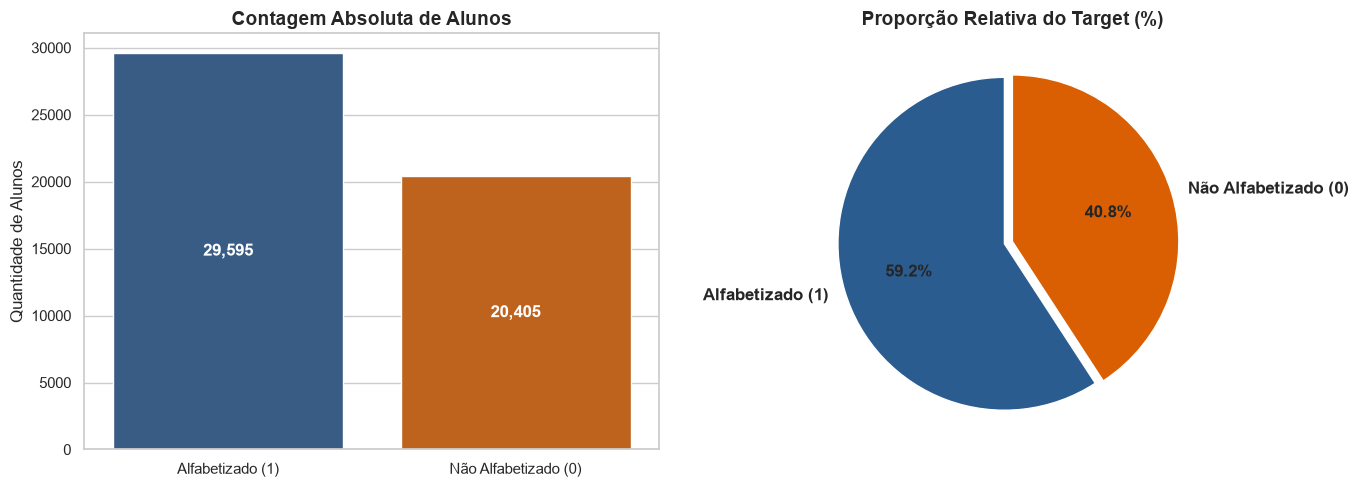

In [5]:
target_counts = df["alfabetizado"].value_counts(normalize=False)
target_pct = df["alfabetizado"].value_counts(normalize=True) * 100

print("=== DISTRIBUIÇÃO DA VARIÁVEL ALVO (alfabetizado) ===")
for val in [1, 0]:
    label = "Alfabetizado (1)" if val == 1 else "Não Alfabetizado (0)"
    print(f"{label}: {target_counts[val]:,} alunos ({target_pct[val]:.2f}%)")

# Gráfico da Variável Alvo
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Barras
palette = ["#2b5c8f", "#d95f02"]
sns.barplot(x=["Alfabetizado (1)", "Não Alfabetizado (0)"], y=target_counts.values, ax=ax[0], palette=palette)
ax[0].set_title("Contagem Absoluta de Alunos", fontweight="bold")
ax[0].set_ylabel("Quantidade de Alunos")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                   ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Gráfico de Pizza
ax[1].pie(target_pct.values, labels=["Alfabetizado (1)", "Não Alfabetizado (0)"], autopct='%1.1f%%',
          startangle=90, colors=palette, explode=(0.05, 0), textprops={'fontsize': 12, 'fontweight': 'bold'})
ax[1].set_title("Proporção Relativa do Target (%)", fontweight="bold")

plt.tight_layout()
plt.savefig("images/eda/01_distribuicao_target.png", dpi=300)
plt.show()


> **Conclusão para Modelagem (Dimensão 1):**  
> A base apresenta **desbalanceamento moderado** (~60% classe 1 vs. ~40% classe 0).  
> Em virtude do impacto social, o erro mais crítico é o **falso negativo** (prever que o aluno está alfabetizado quando ele não está).  
> Portanto, a acurácia simples é insuficiente. As métricas primárias recomendadas para o Scikit-learn são:  
> **ROC-AUC, PR-AUC, F1-Score e Recall da classe 0 (não alfabetizado)**.


---
## Dimensão 2: Disparidades Regionais e Territoriais
*Objetivo: Mapear diferenças macroeconômicas entre Regiões e elencar UFs críticas.*


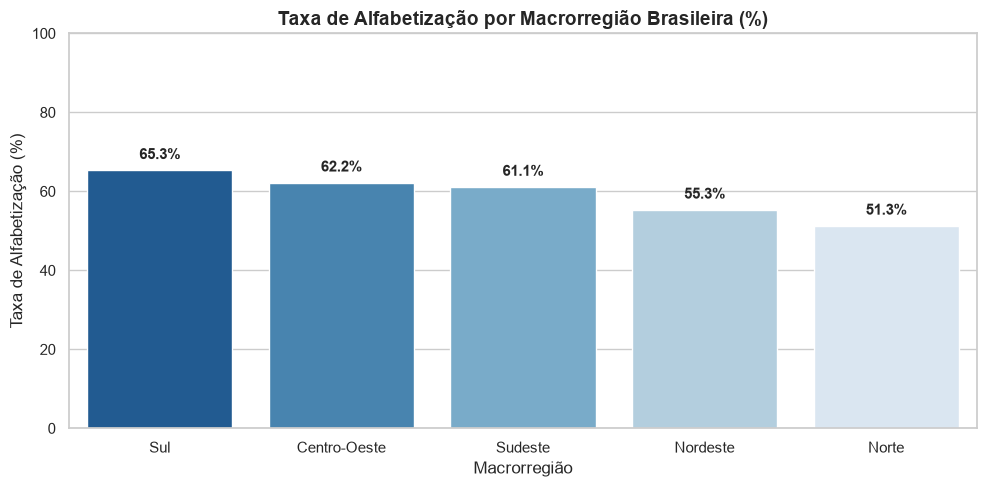

In [6]:
# 1. Taxa por Região
df_regiao = df.groupby("nome_regiao")["alfabetizado"].agg(
    total_alunos="count",
    taxa_alfabetizacao=lambda x: np.mean(x) * 100
).reset_index().sort_values("taxa_alfabetizacao", ascending=False)

plt.figure(figsize=(10, 5))
bar_plot = sns.barplot(data=df_regiao, x="nome_regiao", y="taxa_alfabetizacao", palette="Blues_r")
plt.title("Taxa de Alfabetização por Macrorregião Brasileira (%)", fontweight="bold")
plt.xlabel("Macrorregião")
plt.ylabel("Taxa de Alfabetização (%)")
plt.ylim(0, 100)

for p in bar_plot.patches:
    bar_plot.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("images/eda/02_taxa_por_regiao.png", dpi=300)
plt.show()


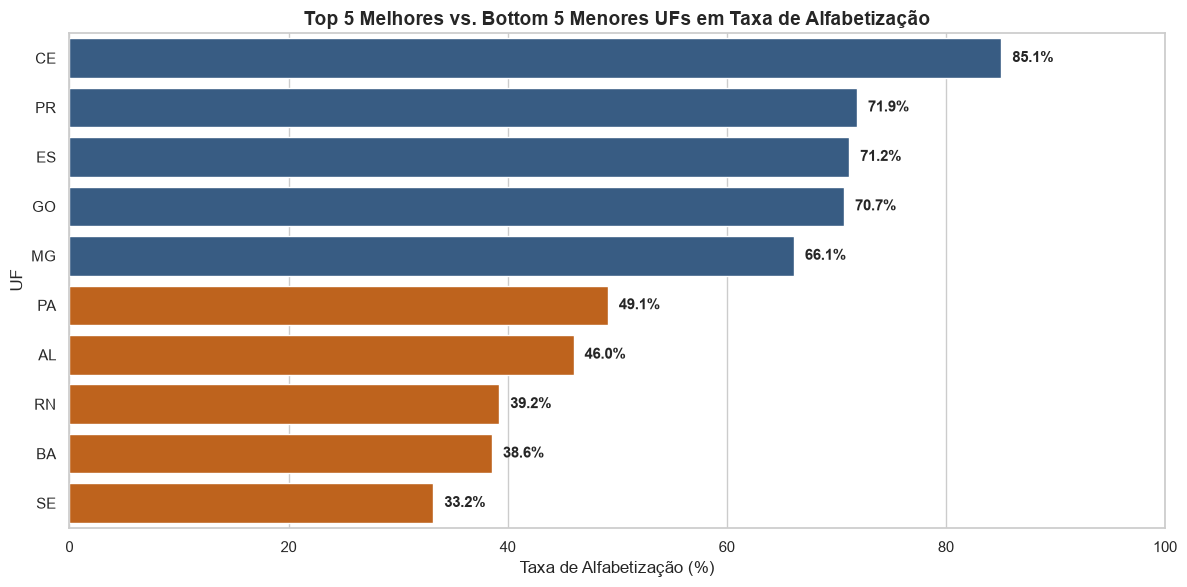

In [7]:
# 2. Ranking de UFs (Top 5 e Bottom 5)
df_uf = df.groupby(["sigla_uf", "nome_regiao"])["alfabetizado"].agg(
    total_alunos="count",
    taxa_alfabetizacao=lambda x: np.mean(x) * 100
).reset_index().sort_values("taxa_alfabetizacao", ascending=False)

top_bottom_uf = pd.concat([df_uf.head(5), df_uf.tail(5)])
colors = ["#2b5c8f"] * 5 + ["#d95f02"] * 5

plt.figure(figsize=(12, 6))
sns.barplot(data=top_bottom_uf, x="taxa_alfabetizacao", y="sigla_uf", palette=colors)
plt.title("Top 5 Melhores vs. Bottom 5 Menores UFs em Taxa de Alfabetização", fontweight="bold")
plt.xlabel("Taxa de Alfabetização (%)")
plt.ylabel("UF")
plt.xlim(0, 100)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.1f}%", (p.get_width() + 1, p.get_y() + p.get_height() / 2.),
                       va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("images/eda/03_ranking_ufs.png", dpi=300)
plt.show()


---
## Dimensão 3: Dependência Administrativa (`rede_label`) e Contexto Escolar
*Objetivo: Avaliar a disparidade entre redes (Municipal vs Estadual vs Privada) e o efeito do tamanho da escola.*


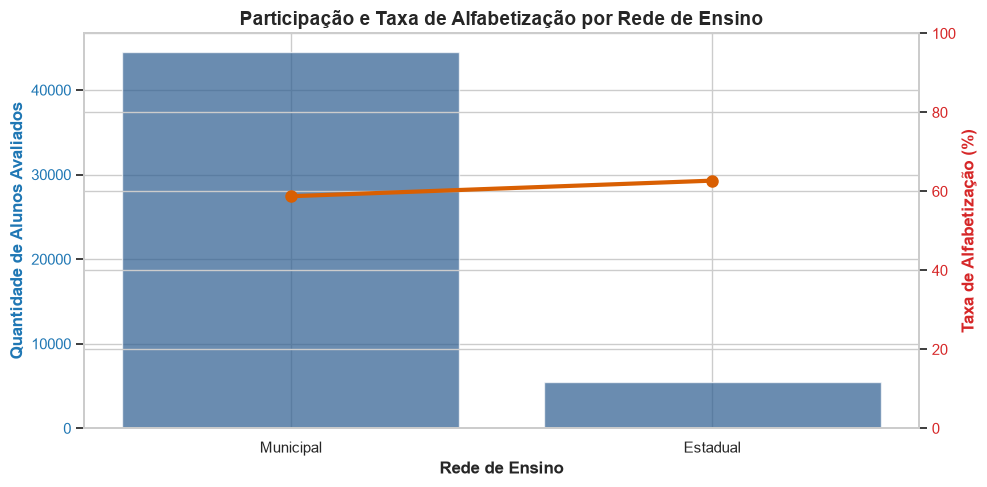

In [8]:
# Taxa por Rede de Ensino
df_rede = df.groupby("rede_label")["alfabetizado"].agg(
    total_alunos="count",
    taxa_alfabetizacao=lambda x: np.mean(x) * 100
).reset_index().sort_values("total_alunos", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eixo 1: Volume de Alunos
color = 'tab:blue'
ax1.set_xlabel("Rede de Ensino", fontweight="bold")
ax1.set_ylabel("Quantidade de Alunos Avaliados", color=color, fontweight="bold")
bars = ax1.bar(df_rede["rede_label"], df_rede["total_alunos"], color="#2b5c8f", alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

# Eixo 2: Taxa de Alfabetização
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Taxa de Alfabetização (%)", color=color, fontweight="bold")
lines = ax2.plot(df_rede["rede_label"], df_rede["taxa_alfabetizacao"], color="#d95f02", marker='o', linewidth=3, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 100)

plt.title("Participação e Taxa de Alfabetização por Rede de Ensino", fontweight="bold")
fig.tight_layout()
plt.savefig("images/eda/04_rede_ensino.png", dpi=300)
plt.show()


---
## Dimensão 4: Vulnerabilidade Socioeconômica (IDHM, Renda, PIB e Abandono)
*Objetivo: Testar como os fatores socioeconômicos separam alunos alfabetizados de não alfabetizados.*

> ⚠️ **Atenção antes de ler os resultados desta dimensão.**
> As colunas `idhm`, `idhm_educacao`, `idhm_renda`, `idhm_longevidade`, `pib_per_capita`,
> `indice_gini`, `taxa_abandono_fundamental`, `populacao_estimada` e `porte_municipio` vêm
> da dimensão `silver.dim_socioeconomico_municipio` e **são sintéticas**: geradas por
> sorteio determinístico em torno das médias regionais do Atlas do Desenvolvimento Humano,
> com semente derivada do código IBGE do município.
>
> O quanto isso é visível: nesta base, **Brasília aparece classificada como município de
> menos de 20 mil habitantes**. O porte foi sorteado, não observado.
>
> Elas existem para exercitar a integração de fontes externas na arquitetura. Qualquer
> padrão observado aqui é, na prática, um reflexo da **região** do município — e não deve
> ser levado ao relatório como achado de política pública. Substituir por Atlas Brasil e
> IBGE/SIDRA é uma troca de uma tabela só.

=== MÉDIAS DOS INDICADORES SOCIOECONÔMICOS POR CLASSE ===
    alfabetizado     idhm  idhm_educacao  idhm_renda  pib_per_capita  taxa_abandono_fundamental
Não Alfabetizado 0.719781       0.652335    0.712253    36079.079781                   1.875031
    Alfabetizado 0.727616       0.661493    0.722435    38423.539448                   1.745793


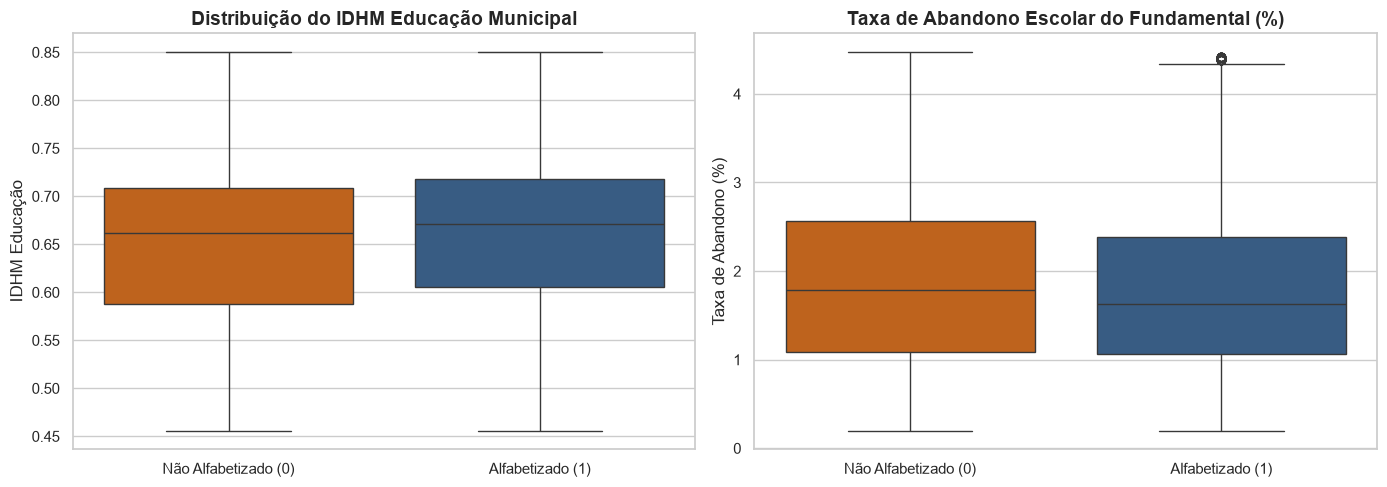

In [9]:
cols_socio = ["idhm", "idhm_educacao", "idhm_renda", "pib_per_capita", "taxa_abandono_fundamental"]
df_socio_summary = df.groupby("alfabetizado")[cols_socio].mean().reset_index()
df_socio_summary["alfabetizado"] = df_socio_summary["alfabetizado"].map({1: "Alfabetizado", 0: "Não Alfabetizado"})

print("=== MÉDIAS DOS INDICADORES SOCIOECONÔMICOS POR CLASSE ===")
print(df_socio_summary.to_string(index=False))

# Boxplots comparativos de IDHM Educação e Abandono
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="alfabetizado", y="idhm_educacao", ax=ax[0], palette=["#d95f02", "#2b5c8f"])
ax[0].set_xticklabels(["Não Alfabetizado (0)", "Alfabetizado (1)"])
ax[0].set_title("Distribuição do IDHM Educação Municipal", fontweight="bold")
ax[0].set_xlabel("")
ax[0].set_ylabel("IDHM Educação")

sns.boxplot(data=df, x="alfabetizado", y="taxa_abandono_fundamental", ax=ax[1], palette=["#d95f02", "#2b5c8f"])
ax[1].set_xticklabels(["Não Alfabetizado (0)", "Alfabetizado (1)"])
ax[1].set_title("Taxa de Abandono Escolar do Fundamental (%)", fontweight="bold")
ax[1].set_xlabel("")
ax[1].set_ylabel("Taxa de Abandono (%)")

plt.tight_layout()
plt.savefig("images/eda/05_boxplot_socioeconomico.png", dpi=300)
plt.show()


---
## Dimensão 5: Histórico Municipal e Metas do INEP (`mun_gap_meta_2024`)
*Objetivo: Verificar se o histórico de cumprimento de metas municipais é preditor da probabilidade individual.*


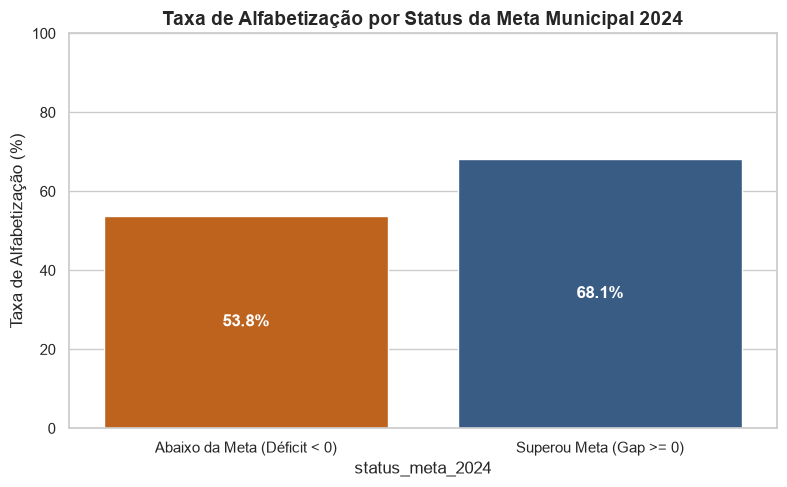

In [10]:
df["status_meta_2024"] = np.where(df["mun_gap_meta_2024"] >= 0, "Superou Meta (Gap >= 0)", "Abaixo da Meta (Déficit < 0)")
gap_summary = df.groupby("status_meta_2024")["alfabetizado"].agg(
    total_alunos="count",
    taxa_alfabetizacao=lambda x: np.mean(x) * 100
).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=gap_summary, x="status_meta_2024", y="taxa_alfabetizacao", palette=["#d95f02", "#2b5c8f"])
plt.title("Taxa de Alfabetização por Status da Meta Municipal 2024", fontweight="bold")
plt.ylabel("Taxa de Alfabetização (%)")
plt.ylim(0, 100)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                       ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig("images/eda/06_gap_metas.png", dpi=300)
plt.show()


---
## Dimensão 6: Matriz de Correlação e Seleção de Atributos
*Objetivo: Detectar correlações lineares com o target e identificar multicolinearidade entre variáveis preditoras.*


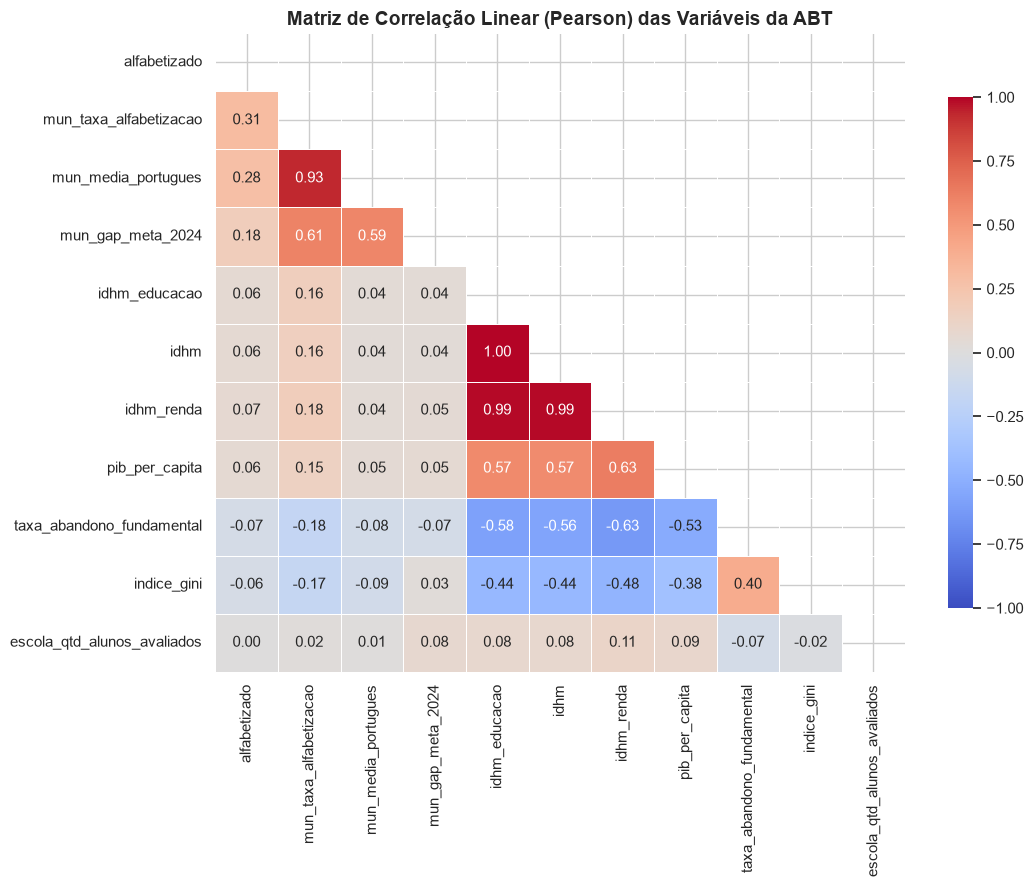

=== CORRELAÇÃO DE CADA VARIÁVEL COM O TARGET (alfabetizado) ===
mun_taxa_alfabetizacao         0.305373
mun_media_portugues            0.283349
mun_gap_meta_2024              0.176271
idhm_renda                     0.065890
idhm_educacao                  0.060542
idhm                           0.058418
pib_per_capita                 0.055281
escola_qtd_alunos_avaliados    0.003983
indice_gini                   -0.061611
taxa_abandono_fundamental     -0.069258


In [11]:
features_corr = [
    "alfabetizado",
    "mun_taxa_alfabetizacao",
    "mun_media_portugues",
    "mun_gap_meta_2024",
    "idhm_educacao",
    "idhm",
    "idhm_renda",
    "pib_per_capita",
    "taxa_abandono_fundamental",
    "indice_gini",
    "escola_qtd_alunos_avaliados"
]

corr_matrix = df[features_corr].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, mask=mask, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação Linear (Pearson) das Variáveis da ABT", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/eda/07_matriz_correlacao.png", dpi=300)
plt.show()

# Ranking de Correlação direta com 'alfabetizado'
corr_with_target = corr_matrix["alfabetizado"].drop("alfabetizado").sort_values(ascending=False)
print("=== CORRELAÇÃO DE CADA VARIÁVEL COM O TARGET (alfabetizado) ===")
print(corr_with_target.to_string())


---
## Dimensão 7: Auditoria de Vazamento de Alvo (*Target Leakage*)

*Objetivo: verificar se alguma variável candidata a preditora carrega, de forma
disfarçada, a própria resposta.*

Esta checagem é o que separa um modelo honesto de um modelo que parece bom.
Duas variáveis merecem suspeita:

1. **`proficiencia_audit_only`** — é a nota no Saeb, e o aluno é considerado
   alfabetizado se ela for maior ou igual a **743**. Não é preditor: é o alvo
   escrito de outro jeito. Está na ABT apenas para auditoria.
2. **`mun_taxa_alfabetizacao`** — parece contexto do município, mas vem da
   avaliação **do mesmo ano do aluno**, e por definição é a média do alvo
   naquele município — com o próprio aluno dentro dela.

=== PROFICIÊNCIA vs ALVO (corte oficial do INEP: 743 pontos) ===
                     alunos  taxa_alfabetizados
Proficiência < 743    20405                 0.0
Proficiência >= 743   29595               100.0

A separação é perfeita: a nota NÃO é preditor, é o alvo reescrito.



=== INDICADOR MUNICIPAL vs MÉDIA DO ALVO NO MUNICÍPIO ===
  Indicador do MESMO ano   : correlação = 0.9930  (9,437 pares município-ano)
  Indicador do ANO ANTERIOR: correlação = 0.6871  (4,945 pares)


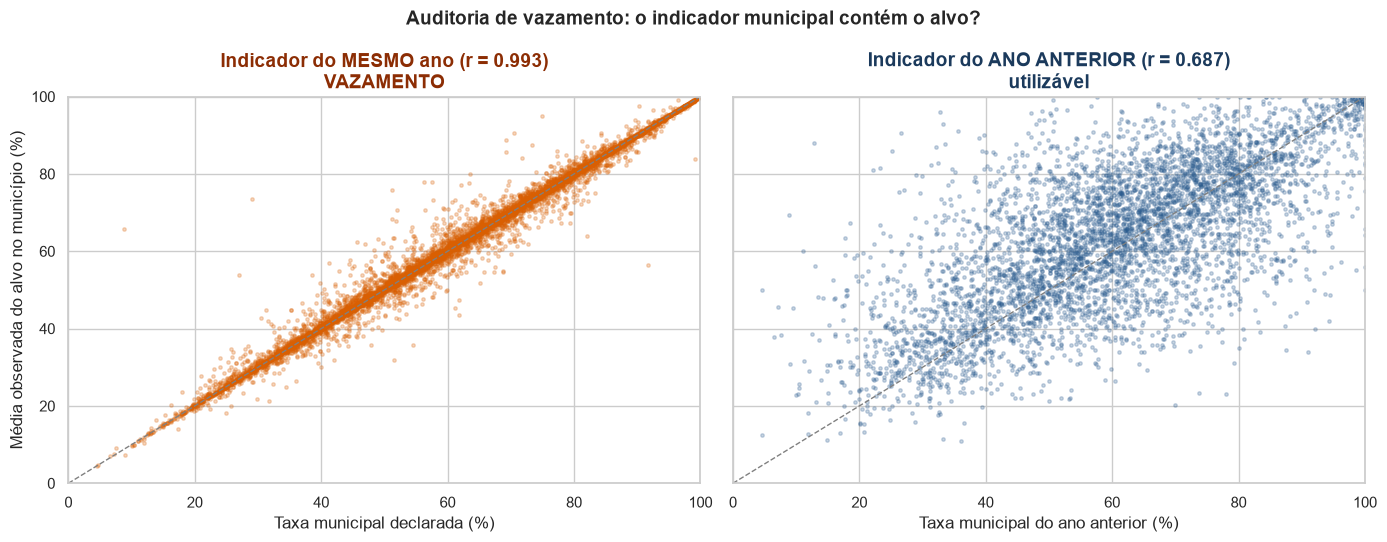

In [12]:
# --- 1. A proficiência é o alvo disfarçado? ---
corte = df.groupby(df["proficiencia_audit_only"] >= 743)["alfabetizado"].agg(
    alunos="count", taxa_alfabetizados="mean"
)
corte.index = ["Proficiência < 743", "Proficiência >= 743"]
corte["taxa_alfabetizados"] = (corte["taxa_alfabetizados"] * 100).round(2)
print("=== PROFICIÊNCIA vs ALVO (corte oficial do INEP: 743 pontos) ===")
print(corte.to_string())
print("\nA separação é perfeita: a nota NÃO é preditor, é o alvo reescrito.")

# --- 2. O indicador municipal do mesmo ano contém o alvo? ---
query_vaz = f"""
WITH alvo AS (
  SELECT ano, id_municipio, AVG(alfabetizado) * 100 AS taxa_alvo, COUNT(*) AS n
  FROM `{TABLE_ABT}`
  GROUP BY ano, id_municipio
  HAVING COUNT(*) >= 30
),
indicador AS (
  SELECT DISTINCT ano, id_municipio,
         mun_taxa_alfabetizacao, mun_taxa_alfabetizacao_ant
  FROM `{TABLE_ABT}`
)
SELECT a.ano, a.taxa_alvo, a.n,
       i.mun_taxa_alfabetizacao     AS mesmo_ano,
       i.mun_taxa_alfabetizacao_ant AS ano_anterior
FROM alvo a
JOIN indicador i USING (ano, id_municipio)
"""
df_vaz = client.query(query_vaz).to_dataframe()

corr_mesmo = df_vaz[["taxa_alvo", "mesmo_ano"]].corr().iloc[0, 1]
sub = df_vaz.dropna(subset=["ano_anterior"])
corr_ant = sub[["taxa_alvo", "ano_anterior"]].corr().iloc[0, 1]

print(f"\n=== INDICADOR MUNICIPAL vs MÉDIA DO ALVO NO MUNICÍPIO ===")
print(f"  Indicador do MESMO ano   : correlação = {corr_mesmo:.4f}  "
      f"({len(df_vaz):,} pares município-ano)")
print(f"  Indicador do ANO ANTERIOR: correlação = {corr_ant:.4f}  "
      f"({len(sub):,} pares)")

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
ax[0].scatter(df_vaz["mesmo_ano"], df_vaz["taxa_alvo"], s=6, alpha=0.25, color="#d95f02")
ax[0].set_title(f"Indicador do MESMO ano (r = {corr_mesmo:.3f})\nVAZAMENTO",
                fontweight="bold", color="#8c2d04")
ax[0].set_xlabel("Taxa municipal declarada (%)")
ax[0].set_ylabel("Média observada do alvo no município (%)")

ax[1].scatter(sub["ano_anterior"], sub["taxa_alvo"], s=6, alpha=0.25, color="#2b5c8f")
ax[1].set_title(f"Indicador do ANO ANTERIOR (r = {corr_ant:.3f})\nutilizável",
                fontweight="bold", color="#1b3a5c")
ax[1].set_xlabel("Taxa municipal do ano anterior (%)")

for a in ax:
    a.plot([0, 100], [0, 100], "--", color="gray", lw=1)
    a.set_xlim(0, 100)
    a.set_ylim(0, 100)

plt.suptitle("Auditoria de vazamento: o indicador municipal contém o alvo?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/eda/08_auditoria_vazamento.png", dpi=300, bbox_inches="tight")
plt.show()

> **Conclusão para Modelagem (Dimensão 7):**
>
> A correlação de **0,993** entre `mun_taxa_alfabetizacao` e a média observada do alvo
> no município confirma o vazamento: os pontos caem praticamente sobre a diagonal.
> A variável não descreve o contexto — ela **é** o rótulo agregado.
>
> Com o indicador do **ano anterior** a correlação cai para um patamar que representa
> inércia educacional real do município, não identidade matemática.
>
> **Decisão:** a modelagem usa exclusivamente as colunas com sufixo `_ant`.
> As sem sufixo ficam restritas à descrição, como nesta EDA.
> Consequência: sobram os alunos de 2024, únicos com ano de referência disponível.

---
## Validação das 5 Hipóteses Centrais do Projeto

### Hipótese H1: Desigualdade Regional
*Proposição: Norte e Nordeste apresentam taxas significativamente inferiores ao Sul e Sudeste, mesmo dentro da mesma rede.*


In [13]:
h1_df = df[df["rede_label"].isin(["Municipal", "Estadual"])].copy()
h1_df["macro_bloco"] = np.where(h1_df["nome_regiao"].isin(["Sul", "Sudeste"]), "Sul / Sudeste",
                       np.where(h1_df["nome_regiao"].isin(["Norte", "Nordeste"]), "Norte / Nordeste", "Centro-Oeste"))

h1_res = h1_df.groupby(["macro_bloco", "rede_label"])["alfabetizado"].agg(
    total_alunos="count",
    taxa_pct=lambda x: np.mean(x) * 100
).reset_index()

print("=== VALIDAÇÃO H1: DESIGUALDADE REGIONAL POR REDE ===")
print(h1_res.to_string(index=False))


=== VALIDAÇÃO H1: DESIGUALDADE REGIONAL POR REDE ===
     macro_bloco rede_label  total_alunos  taxa_pct
    Centro-Oeste   Estadual           385 58.181818
    Centro-Oeste  Municipal          4514 62.538768
Norte / Nordeste   Estadual          1046 53.824092
Norte / Nordeste  Municipal         18925 54.224571
   Sul / Sudeste   Estadual          4092 65.395894
   Sul / Sudeste  Municipal         21038 62.016351


### Hipótese H2: Eficiência da Meta Municipal
*Proposição: Alunos em municípios que bateram a meta de 2024 (`gap >= 0`) têm maior taxa de alfabetização (+10 p.p.).*


In [14]:
# O gap do MESMO ano é circular: a taxa que o compõe já contém o aluno.
# Repetimos o teste com o gap do ANO ANTERIOR, que é o teste honesto.
h2_bateu = df[df["mun_gap_meta_2024"] >= 0]["alfabetizado"].mean() * 100
h2_nao = df[df["mun_gap_meta_2024"] < 0]["alfabetizado"].mean() * 100

ant = df.dropna(subset=["mun_gap_meta_2024_ant"])
h2a_bateu = ant[ant["mun_gap_meta_2024_ant"] >= 0]["alfabetizado"].mean() * 100
h2a_nao = ant[ant["mun_gap_meta_2024_ant"] < 0]["alfabetizado"].mean() * 100

print("=== VALIDAÇÃO H2: CUMPRIMENTO DA META MUNICIPAL ===\n")
print("a) Gap do MESMO ano (circular - só para referência):")
print(f"   Meta batida (gap >= 0): {h2_bateu:.2f}%")
print(f"   Déficit     (gap <  0): {h2_nao:.2f}%")
print(f"   Diferença: {h2_bateu - h2_nao:.2f} p.p.\n")

print(f"b) Gap do ANO ANTERIOR (teste válido, {len(ant):,} alunos de 2024):")
print(f"   Meta batida (gap >= 0): {h2a_bateu:.2f}%")
print(f"   Déficit     (gap <  0): {h2a_nao:.2f}%")
diff = h2a_bateu - h2a_nao
print(f"   Diferença: {diff:.2f} p.p.")
print(f"\n   -> Hipótese {'VALIDADA' if diff >= 10 else 'PARCIALMENTE VALIDADA'} "
      f"(proposição previa +10 p.p.)")
print("\nO resultado que vale para o relatório é o (b): o desempenho do município")
print("no ano anterior antecipa o desempenho do aluno no ano seguinte.")

=== VALIDAÇÃO H2: CUMPRIMENTO DA META MUNICIPAL ===

a) Gap do MESMO ano (circular - só para referência):
   Meta batida (gap >= 0): 68.13%
   Déficit     (gap <  0): 53.97%
   Diferença: 14.16 p.p.

b) Gap do ANO ANTERIOR (teste válido, 26,267 alunos de 2024):
   Meta batida (gap >= 0): 69.00%
   Déficit     (gap <  0): 57.89%
   Diferença: 11.10 p.p.

   -> Hipótese VALIDADA (proposição previa +10 p.p.)

O resultado que vale para o relatório é o (b): o desempenho do município
no ano anterior antecipa o desempenho do aluno no ano seguinte.


### Hipótese H3: Dependência do IDHM Educação
*Proposição: O IDHM Educação é o atributo socioeconômico com maior correlação positiva com a alfabetização.*

> ⚠️ Esta hipótese é **inconclusiva por construção**: o IDHM desta base é sintético
> (ver Dimensão 4). O teste abaixo é mantido para deixar registrada a limitação, não
> para sustentar conclusão. Validá-la de verdade exige o IDHM oficial do Atlas Brasil.

In [15]:
print(f"=== VALIDAÇÃO H3 ===")
print(f"Corr(IDHM Educação, target): {corr_matrix.loc['idhm_educacao', 'alfabetizado']:.4f}")
print(f"Corr(IDHM Renda, target):    {corr_matrix.loc['idhm_renda', 'alfabetizado']:.4f}")
print(f"Corr(PIB per capita, target): {corr_matrix.loc['pib_per_capita', 'alfabetizado']:.4f}")


=== VALIDAÇÃO H3 ===
Corr(IDHM Educação, target): 0.0605
Corr(IDHM Renda, target):    0.0659
Corr(PIB per capita, target): 0.0553


### Hipótese H4: Impacto do Abandono Escolar
*Proposição: Municípios com taxa de abandono do fundamental acima de 2,0% têm queda acentuada no desempenho.*

> ⚠️ Mesma ressalva da H3: `taxa_abandono_fundamental` é sintética. O corte de 2,0%
> vem da literatura, mas o dado testado aqui não é observado.

In [16]:
df["faixa_abandono"] = pd.cut(df["taxa_abandono_fundamental"], bins=[-np.inf, 1.0, 2.0, np.inf],
                              labels=["Baixo (< 1.0%)", "Médio (1.0% a 2.0%)", "Alto (> 2.0%)"])
h4_res = df.groupby("faixa_abandono")["alfabetizado"].agg(
    total_alunos="count",
    taxa_pct=lambda x: np.mean(x) * 100
).reset_index()

print("=== VALIDAÇÃO H4: ABANDONO ESCOLAR ===")
print(h4_res.to_string(index=False))


=== VALIDAÇÃO H4: ABANDONO ESCOLAR ===
     faixa_abandono  total_alunos  taxa_pct
     Baixo (< 1.0%)         10001 62.243776
Médio (1.0% a 2.0%)         20229 61.574967
      Alto (> 2.0%)         19770 55.204856


### Hipótese H5: Estabilidade Escolar por Porte
*Proposição: Escolas com maior contingente de alunos avaliados possuem taxas mais estáveis de alfabetização.*


=== VALIDAÇÃO H5: ESTABILIDADE POR PORTE ESCOLAR ===
    (42,328 escolas avaliadas em 2024)

  faixa_escola  qtd_escolas  taxa_media  desvio_padrao
Pequena (< 20)        11768   56.853136      26.938925
 Média (20-50)        17303   59.205653      22.030309
 Grande (> 50)        13257   60.539361      18.290417

Desvio-padrão da taxa: 26.94 nas escolas pequenas contra 18.29 nas grandes.
-> Hipótese VALIDADA: escolas maiores têm taxas mais estáveis.

Isso é esperado estatisticamente (média de mais alunos varia menos), e tem
consequência prática: ranquear escolas pequenas por taxa produz falsos extremos.


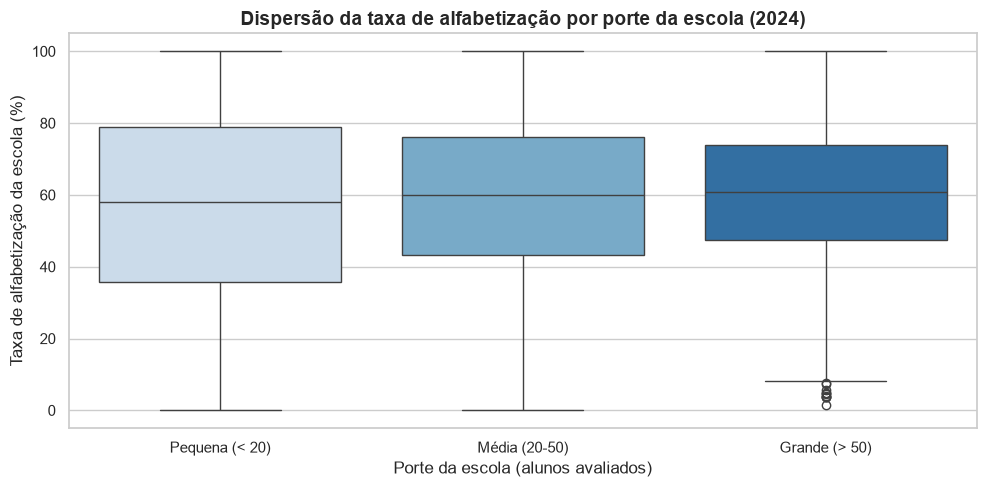

In [17]:
# A amostra de 50 mil alunos sorteia ~1 aluno por escola, então contar alunos
# por escola DENTRO dela não mede nada. O porte real vem da coluna
# `escola_qtd_alunos_avaliados` da ABT, e a taxa por escola sai de uma
# agregação sobre a tabela inteira.
query_h5 = f"""
SELECT
  id_escola,
  ANY_VALUE(escola_qtd_alunos_avaliados) AS total_avaliados,
  AVG(alfabetizado) * 100                AS taxa_escola
FROM `{TABLE_ABT}`
WHERE ano = 2024
GROUP BY id_escola
"""
escolas_agg = client.query(query_h5).to_dataframe()

escolas_agg["faixa_escola"] = pd.cut(
    escolas_agg["total_avaliados"], bins=[-np.inf, 20, 50, np.inf],
    labels=["Pequena (< 20)", "Média (20-50)", "Grande (> 50)"],
)
h5_res = escolas_agg.groupby("faixa_escola", observed=True)["taxa_escola"].agg(
    qtd_escolas="count", taxa_media="mean", desvio_padrao="std"
).reset_index()

print(f"=== VALIDAÇÃO H5: ESTABILIDADE POR PORTE ESCOLAR ===")
print(f"    ({len(escolas_agg):,} escolas avaliadas em 2024)\n")
print(h5_res.to_string(index=False))

dp = h5_res.set_index("faixa_escola")["desvio_padrao"]
if {"Pequena (< 20)", "Grande (> 50)"}.issubset(dp.index):
    print(f"\nDesvio-padrão da taxa: {dp['Pequena (< 20)']:.2f} nas escolas pequenas "
          f"contra {dp['Grande (> 50)']:.2f} nas grandes.")
    print(f"-> Hipótese {'VALIDADA' if dp['Grande (> 50)'] < dp['Pequena (< 20)'] else 'REFUTADA'}: "
          "escolas maiores têm taxas mais estáveis.")
    print("\nIsso é esperado estatisticamente (média de mais alunos varia menos), e tem")
    print("consequência prática: ranquear escolas pequenas por taxa produz falsos extremos.")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=escolas_agg.dropna(subset=["faixa_escola"]),
            x="faixa_escola", y="taxa_escola", ax=ax, palette="Blues")
ax.set_title("Dispersão da taxa de alfabetização por porte da escola (2024)",
             fontweight="bold")
ax.set_xlabel("Porte da escola (alunos avaliados)")
ax.set_ylabel("Taxa de alfabetização da escola (%)")
plt.tight_layout()
plt.savefig("images/eda/09_estabilidade_por_porte_escola.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Conclusão e Diretrizes para o Pipeline de Machine Learning

O que esta EDA determina sobre a modelagem:

1. **Métrica norte.** O alvo está em ~60/40. O erro caro é o falso negativo — deixar de
   sinalizar uma criança em risco. Métricas primárias: **Recall da classe 0**, **PR-AUC**
   e **ROC-AUC**. Acurácia simples é insuficiente: um modelo que chutasse sempre
   "alfabetizado" acertaria ~60% com Recall da classe 0 igual a zero.

2. **Vazamento de alvo (Dimensão 7).** `proficiencia_audit_only` é o alvo reescrito e está
   fora da matriz preditora. `mun_taxa_alfabetizacao` do mesmo ano correlaciona 0,993 com a
   média do alvo no município: a modelagem usa apenas as versões `_ant`, do ano anterior.

3. **Multicolinearidade.** O `idhm` geral é combinação linear das três dimensões que o
   compõem. Mantém-se `idhm_educacao` e `idhm_renda`, descartando o `idhm` agregado.

4. **Encoding.** `sigla_uf`, `nome_regiao`, `porte_municipio` e `rede_label` entram por
   `OneHotEncoder(handle_unknown="ignore")` dentro do `Pipeline`.

5. **Ausentes.** `SimpleImputer(strategy="median")` para numéricas e `"most_frequent"`
   para categóricas — sempre ajustado **só no conjunto de treino**.

6. **Peso amostral.** `peso_aluno` não é atributo do aluno e fica fora das features. Ele
   reaparece na amostragem do SHAP, para que a explicação represente a população de
   crianças e não apenas o arquivo.

7. **Limite esperado de performance.** Todas as variáveis disponíveis são de contexto
   municipal, estadual ou de rede — não há atributo individual do aluno além de `caderno`
   e `serie`. O modelo tende a separar municípios, não alunos da mesma escola.